# Winds and Wind Effects on Flight Planning

This notebook covers both **wind data sources** and their **effects
on airborne survey planning**:

**Part I — Wind Data Sources**
1. Still air and constant wind fields
2. Wind direction and speed sensitivity
3. Gridded wind fields (MERRA-2, GFS, GMAO)
4. Factory function for automated wind setup

**Part II — Wind Effects on Surveys**
5. Crab angle on flight lines (Twin Otter, ER-2)
6. Swath rotation from crab
7. Trochoidal Dubins transit paths
8. Total mission timing impact


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import datetime
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
import folium

from hyplan import (
    FlightLine, DubinsPath3D,
    DynamicAviation_B200,
    Airport, initialize_data,
    compute_flight_plan, plot_flight_plan, plot_altitude_trajectory,
    ureg,
)
from hyplan.aircraft import TwinOtter, NASA_ER2
from hyplan.instruments import GLiHT_VNIR, AVIRISClassic
from hyplan.winds import (
    StillAirField, ConstantWindField,
    wind_field_from_plan,
)
from hyplan.swath import generate_swath_polygon, calculate_swath_widths
from hyplan.flight_box import box_around_center_line


## 1. Setup: Flight Lines and Aircraft

We set up a simple mission with three east–west flight lines near Santa
Barbara at FL200 (20,000 ft). The B200 cruises at ~250 kt TAS at this
altitude, so wind effects on timing will be significant.

In [2]:
initialize_data(countries=["US"])

aircraft = DynamicAviation_B200()
departure = Airport("KSBA")

# Three east-west flight lines
flight_lines = []
for i, lat in enumerate([34.40, 34.35, 34.30]):
    az = 90.0 if i % 2 == 0 else 270.0  # alternating direction
    fl = FlightLine.center_length_azimuth(
        lat=lat, lon=-119.8,
        length=ureg.Quantity(80, "km"),
        az=az,
        altitude_msl=ureg.Quantity(20000, "feet"),
        site_name=f"Coastal_L{i+1:02d}",
    )
    flight_lines.append(fl)

print(f"Aircraft: {type(aircraft).__name__}")
print(f"Departure: {departure.name} ({departure.icao_code})")
print(f"\n{len(flight_lines)} flight lines (alternating E/W):")
for fl in flight_lines:
    print(f"  {fl.site_name}: {fl.length.to(ureg.km):.1f}, az={fl.az12:.0f}")

Aircraft: DynamicAviation_B200
Departure: Santa Barbara Municipal Airport (KSBA)

3 flight lines (alternating E/W):
  Coastal_L01: 80.0 kilometer, az=90 degree
  Coastal_L02: 80.0 kilometer, az=270 degree
  Coastal_L03: 80.0 kilometer, az=90 degree


## 2. Still Air and Constant Wind

`StillAirField` always returns zero wind — it is equivalent to omitting
the `wind_source` parameter entirely. `ConstantWindField` wraps a single
speed and direction into U/V components using meteorological convention
(direction is where the wind blows *from*).

In [3]:
still = StillAirField()
u, v = still.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"Still air:  U={u.m_as('knot'):.1f} kt, V={v.m_as('knot'):.1f} kt")

# 40 kt wind from the west (blows eastward)
westerly = ConstantWindField(wind_speed=40 * ureg.knot, wind_from_deg=270.0)
u, v = westerly.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"40 kt from west:  U={u.m_as('knot'):+.1f} kt, V={v.m_as('knot'):+.1f} kt")

# 30 kt wind from the northwest
nw_wind = ConstantWindField(wind_speed=30 * ureg.knot, wind_from_deg=315.0)
u, v = nw_wind.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"30 kt from NW:    U={u.m_as('knot'):+.1f} kt, V={v.m_as('knot'):+.1f} kt")

Still air:  U=0.0 kt, V=0.0 kt
40 kt from west:  U=+40.0 kt, V=+0.0 kt
30 kt from NW:    U=+21.2 kt, V=-21.2 kt


## 3. Comparing Flight Plans With and Without Wind

A 40 kt westerly wind is a headwind on eastbound legs and a tailwind
on westbound legs. Wind affects both the **timing** and the **geometry**
of Dubins transit paths (turning arcs become trochoids). Flight line
segments use a simple headwind/tailwind correction along the line
bearing, while transit, departure, and return legs use the full
wind-aware 3D Dubins solver.

In [4]:
plan_still = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=flight_lines,
    takeoff_airport=departure,
    return_airport=departure,
)

plan_wind = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=flight_lines,
    takeoff_airport=departure,
    return_airport=departure,
    wind_source=westerly,
)

# Side-by-side comparison
cols = ["segment_type", "segment_name", "time_to_segment"]
comparison = plan_still[cols].copy()
comparison.columns = ["type", "segment", "still_air_min"]
comparison["with_wind_min"] = plan_wind["time_to_segment"].values
comparison["delta_min"] = comparison["with_wind_min"] - comparison["still_air_min"]

print(comparison.to_string(index=False, float_format="%.2f"))
print(f"\nTotal still air:  {comparison['still_air_min'].sum():.1f} min")
print(f"Total with wind:  {comparison['with_wind_min'].sum():.1f} min")
print(f"Net difference:   {comparison['delta_min'].sum():+.1f} min")

       type                    segment  still_air_min  with_wind_min  delta_min
    takeoff                  Departure          10.06          10.07       0.01
flight_line                Coastal_L01          13.29          11.26      -2.03
    transit Coastal_L01 to Coastal_L02           2.13           1.81      -0.32
flight_line                Coastal_L02          13.29          16.21       2.92
    transit Coastal_L02 to Coastal_L03           2.13           2.59       0.46
flight_line                Coastal_L03          13.29          11.26      -2.03
    descent                     Return          13.39          13.40       0.01

Total still air:  67.6 min
Total with wind:  66.6 min
Net difference:   -1.0 min


## 4. Wind Direction Sensitivity

How does a 40 kt wind from different directions affect total mission
time? We sweep wind direction from 0° (north) through 360° and plot
the resulting flight time.

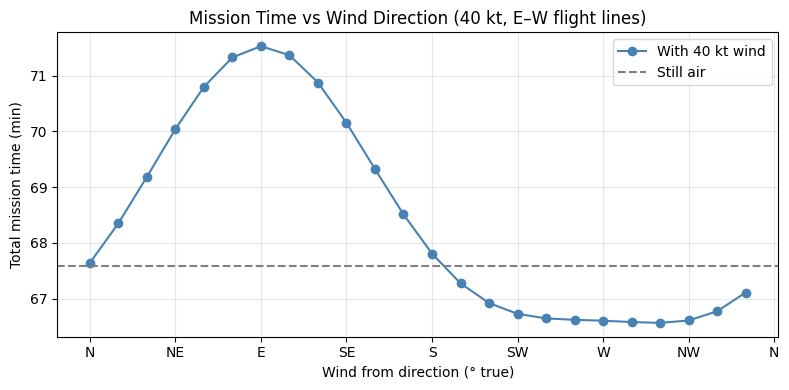

In [5]:
directions = np.arange(0, 360, 15)
times = []
ws = 40 * ureg.knot

for d in directions:
    wf = ConstantWindField(wind_speed=ws, wind_from_deg=float(d))
    plan = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf,
    )
    times.append(plan["time_to_segment"].sum())

baseline = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=flight_lines,
    takeoff_airport=departure,
    return_airport=departure,
)["time_to_segment"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(directions, times, "o-", color="steelblue", label="With 40 kt wind")
ax.axhline(baseline, color="gray", linestyle="--", label="Still air")
ax.set_xlabel("Wind from direction (\u00b0 true)")
ax.set_ylabel("Total mission time (min)")
ax.set_title("Mission Time vs Wind Direction (40 kt, E\u2013W flight lines)")
ax.set_xticks(np.arange(0, 361, 45))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# The worst case is always a headwind along the dominant flight axis.
# For E-W lines, wind from the east or west has the largest effect.
# Crosswinds (N/S) have minimal impact on timing.

## 5. Wind Speed Sensitivity

How does increasing wind speed affect mission time? With alternating
east/west flight lines, *any* wind increases total mission time because
headwind penalties always exceed tailwind savings. We compare wind from
the east vs west at various speeds.

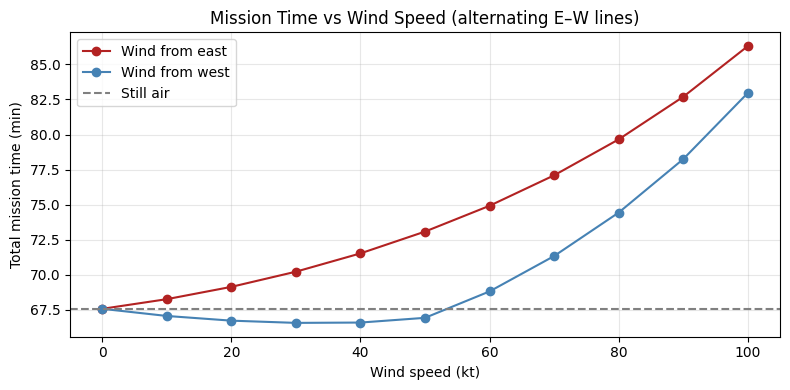

Still air baseline: 67.6 min
At 100 kt from east: 86.3 min (+28%)
At 100 kt from west: 83.0 min (+23%)

Both directions increase total time — headwind penalty
always exceeds tailwind savings on reciprocal legs.


In [6]:
speeds_kt = np.arange(0, 101, 10)
times_from_east = []
times_from_west = []

for s in speeds_kt:
    for direction, result_list in [(90.0, times_from_east), (270.0, times_from_west)]:
        wf = ConstantWindField(wind_speed=s * ureg.knot, wind_from_deg=direction)
        plan = compute_flight_plan(
            aircraft=aircraft,
            flight_sequence=flight_lines,
            takeoff_airport=departure,
            return_airport=departure,
            wind_source=wf,
        )
        result_list.append(plan["time_to_segment"].sum())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(speeds_kt, times_from_east, "o-", color="firebrick", label="Wind from east")
ax.plot(speeds_kt, times_from_west, "o-", color="steelblue", label="Wind from west")
ax.axhline(times_from_east[0], color="gray", linestyle="--", label="Still air")
ax.set_xlabel("Wind speed (kt)")
ax.set_ylabel("Total mission time (min)")
ax.set_title("Mission Time vs Wind Speed (alternating E\u2013W lines)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

baseline = times_from_east[0]
print(f"Still air baseline: {baseline:.1f} min")
print(f"At 100 kt from east: {times_from_east[-1]:.1f} min ({(times_from_east[-1]/baseline-1)*100:+.0f}%)")
print(f"At 100 kt from west: {times_from_west[-1]:.1f} min ({(times_from_west[-1]/baseline-1)*100:+.0f}%)")
print(f"\nBoth directions increase total time \u2014 headwind penalty")
print(f"always exceeds tailwind savings on reciprocal legs.")

## 6. MERRA-2 Reanalysis Winds (Historical)

For planning against historical data (“what were winds on this date
last year?”), use `wind_field_from_plan("merra2", ...)`. This fetches
3-hourly U/V winds on 42 pressure levels at 0.5° resolution via
OPeNDAP from NASA GES DISC.

**Prerequisites:** Set the `EARTHDATA_TOKEN` environment variable or
add your NASA Earthdata credentials to `~/.netrc`. Register at
https://urs.earthdata.nasa.gov if needed.

The `wind_field_from_plan` factory computes the geographic and temporal
bounding box from your flight sequence and fetches only the necessary
sub-region (server-side subsetting via OPeNDAP).

In [7]:
import os

# Only run this cell if Earthdata credentials are available
has_earthdata = (
    os.environ.get("EARTHDATA_TOKEN")
    or os.path.exists(os.path.expanduser("~/.netrc"))
)

if has_earthdata:
    takeoff_time = datetime.datetime(2024, 6, 15, 14, 0, tzinfo=datetime.timezone.utc)

    wf_merra2 = wind_field_from_plan(
        "merra2",
        flight_lines,
        takeoff_time,
        takeoff_airport=departure,
        return_airport=departure,
    )

    # Query the wind at a representative point
    u, v = wf_merra2.wind_at(
        34.4, -119.8, 20000 * ureg.feet, takeoff_time,
    )
    ws = np.sqrt(u.m_as("knot")**2 + v.m_as("knot")**2)
    wdir = (270 - np.degrees(np.arctan2(v.m_as("m/s"), u.m_as("m/s")))) % 360
    print(f"MERRA-2 wind at FL200, 2024-06-15 14:00 UTC:")
    print(f"  U = {u.m_as('knot'):+.1f} kt, V = {v.m_as('knot'):+.1f} kt")
    print(f"  Speed = {ws:.0f} kt from {wdir:.0f}\u00b0")
else:
    print("Earthdata credentials not found. Skipping MERRA-2 demo.")
    print("Set EARTHDATA_TOKEN or add credentials to ~/.netrc.")

/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(
/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


MERRA-2 wind at FL200, 2024-06-15 14:00 UTC:
  U = +31.5 kt, V = +0.3 kt
  Speed = 32 kt from 269°


### Flight Plan with MERRA-2 Winds

Compare the flight plan computed with MERRA-2 reanalysis winds against
the still-air baseline.

In [8]:
if has_earthdata:
    plan_merra2 = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf_merra2,
        takeoff_time=takeoff_time,
    )

    # Compare
    cols = ["segment_type", "segment_name", "time_to_segment"]
    comp = plan_still[cols].copy()
    comp.columns = ["type", "segment", "still_air"]
    comp["merra2"] = plan_merra2["time_to_segment"].values
    comp["delta"] = comp["merra2"] - comp["still_air"]

    print(comp.to_string(index=False, float_format="%.2f"))
    print(f"\nTotal still air: {comp['still_air'].sum():.1f} min")
    print(f"Total MERRA-2:   {comp['merra2'].sum():.1f} min")
    print(f"Difference:      {comp['delta'].sum():+.1f} min")
else:
    print("Skipped (no Earthdata credentials).")

       type                    segment  still_air  merra2  delta
    takeoff                  Departure      10.06   10.07   0.00
flight_line                Coastal_L01      13.29   11.60  -1.69
    transit Coastal_L01 to Coastal_L02       2.13    1.88  -0.25
flight_line                Coastal_L02      13.29   15.35   2.06
    transit Coastal_L02 to Coastal_L03       2.13    2.48   0.35
flight_line                Coastal_L03      13.29   11.65  -1.64
    descent                     Return      13.39   13.39   0.00

Total still air: 67.6 min
Total MERRA-2:   66.4 min
Difference:      -1.2 min


## 7. GFS Forecast Winds (Operational)

NOAA's Global Forecast System (GFS) provides 0.25° resolution wind
forecasts out to 16 days, updated every 6 hours. No credentials
are needed.

`GFSWindField` uses the NOMADS GRIB filter for server-side subsetting —
only the requested variables, pressure levels, and geographic region
are downloaded (~10 KB vs ~500 MB for a full file).

`wind_field_from_plan` automatically selects the most recent GFS cycle
and the forecast hour closest to your mission time.

In [9]:
# Use a takeoff time a few hours from now (within GFS forecast range)
gfs_takeoff = datetime.datetime.now(tz=datetime.timezone.utc) + datetime.timedelta(hours=6)

try:
    wf_gfs = wind_field_from_plan(
        "gfs",
        flight_lines,
        gfs_takeoff,
        takeoff_airport=departure,
        return_airport=departure,
    )

    # Query the wind at a representative point
    u, v = wf_gfs.wind_at(34.4, -119.8, 20000 * ureg.feet, gfs_takeoff)
    ws = np.sqrt(u.m_as('knot')**2 + v.m_as('knot')**2)
    wdir = (270 - np.degrees(np.arctan2(v.m_as('m/s'), u.m_as('m/s')))) % 360
    print(f"GFS wind at FL200, {gfs_takeoff:%Y-%m-%d %H:%M} UTC:")
    print(f"  U = {u.m_as('knot'):+.1f} kt, V = {v.m_as('knot'):+.1f} kt")
    print(f"  Speed = {ws:.0f} kt from {wdir:.0f}\u00b0")
    has_gfs = True
except Exception as e:
    print(f"GFS unavailable: {e}")
    has_gfs = False

GFS wind at FL200, 2026-04-11 10:09 UTC:
  U = +32.3 kt, V = +2.7 kt
  Speed = 32 kt from 265°


### Flight Plan with GFS Winds

Compare the GFS-corrected flight plan against the still-air baseline.

In [10]:
if has_gfs:
    plan_gfs = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf_gfs,
        takeoff_time=gfs_takeoff,
    )

    cols = ["segment_type", "segment_name", "time_to_segment"]
    comp = plan_still[cols].copy()
    comp.columns = ["type", "segment", "still_air"]
    comp["gfs"] = plan_gfs["time_to_segment"].values
    comp["delta"] = comp["gfs"] - comp["still_air"]

    print(comp.to_string(index=False, float_format="%.2f"))
    print(f"\nTotal still air: {comp['still_air'].sum():.1f} min")
    print(f"Total GFS:       {comp['gfs'].sum():.1f} min")
    print(f"Difference:      {comp['delta'].sum():+.1f} min")
else:
    print("Skipped (GFS endpoint unavailable).")

       type                    segment  still_air   gfs  delta
    takeoff                  Departure      10.06 10.07   0.00
flight_line                Coastal_L01      13.29 11.67  -1.62
    transit Coastal_L01 to Coastal_L02       2.13  1.86  -0.27
flight_line                Coastal_L02      13.29 15.67   2.38
    transit Coastal_L02 to Coastal_L03       2.13  2.48   0.35
flight_line                Coastal_L03      13.29 11.67  -1.62
    descent                     Return      13.39 13.39   0.00

Total still air: 67.6 min
Total GFS:       66.8 min
Difference:      -0.8 min


## 8. GMAO GEOS-FP Winds (Near-Real-Time)

NASA GMAO provides GEOS-FP analysis fields at 0.25° resolution,
typically covering the last ~30 days. No credentials required.

> **Note:** The GMAO Fluid OPeNDAP server may be intermittently
> unavailable. This demo is wrapped in a try/except.


In [11]:
gmao_takeoff = datetime.datetime.now(tz=datetime.timezone.utc)

try:
    wf_gmao = wind_field_from_plan(
        "gmao",
        flight_lines,
        gmao_takeoff,
        takeoff_airport=departure,
        return_airport=departure,
    )

    u, v = wf_gmao.wind_at(34.4, -119.8, 20000 * ureg.feet, gmao_takeoff)
    ws = np.sqrt(u.m_as('knot')**2 + v.m_as('knot')**2)
    wdir = (270 - np.degrees(np.arctan2(v.m_as('m/s'), u.m_as('m/s')))) % 360
    print(f"GEOS-FP wind at FL200, {gmao_takeoff:%Y-%m-%d %H:%M} UTC:")
    print(f"  U = {u.m_as('knot'):+.1f} kt, V = {v.m_as('knot'):+.1f} kt")
    print(f"  Speed = {ws:.0f} kt from {wdir:.0f}°")
    has_gmao = True
except Exception as e:
    print(f"GMAO unavailable: {e}")
    has_gmao = False

GEOS-FP wind at FL200, 2026-04-11 04:09 UTC:
  U = +20.2 kt, V = +22.2 kt
  Speed = 30 kt from 222°


### Flight Plan with GEOS-FP Winds


In [12]:
if has_gmao:
    plan_gmao = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf_gmao,
        takeoff_time=gmao_takeoff,
    )

    cols = ["segment_type", "segment_name", "time_to_segment"]
    comp = plan_still[cols].copy()
    comp.columns = ["type", "segment", "still_air"]
    comp["gmao"] = plan_gmao["time_to_segment"].values
    comp["delta"] = comp["gmao"] - comp["still_air"]

    print(comp.to_string(index=False, float_format="%.2f"))
    print(f"\nTotal still air: {comp['still_air'].sum():.1f} min")
    print(f"Total GEOS-FP:   {comp['gmao'].sum():.1f} min")
    print(f"Difference:      {comp['delta'].sum():+.1f} min")
else:
    print("Skipped (GMAO endpoint unavailable).")

       type                    segment  still_air  gmao  delta
    takeoff                  Departure      10.06 10.07   0.00
flight_line                Coastal_L01      13.29 12.07  -1.22
    transit Coastal_L01 to Coastal_L02       2.13  2.02  -0.12
flight_line                Coastal_L02      13.29 14.51   1.22
    transit Coastal_L02 to Coastal_L03       2.13  2.43   0.30
flight_line                Coastal_L03      13.29 12.04  -1.25
    descent                     Return      13.39 13.39   0.00

Total still air: 67.6 min
Total GEOS-FP:   66.5 min
Difference:      -1.1 min


## 9. Using the Factory Function

The `wind_field_from_plan` factory is the recommended way to create wind
fields. It computes the spatial/temporal bounding box from your flight
sequence and only downloads the data you need.

| Source | Description |
|--------|-------------|
| `"still_air"` | Zero wind everywhere |
| `"merra2"` | NASA MERRA-2 reanalysis (historical) |
| `"gfs"` | NOAA GFS forecast (operational, 1-16 days) |
| `"gmao"` | NASA GEOS-FP near-real-time analysis |

In [13]:
# Still air via factory
wf_still = wind_field_from_plan(
    "still_air",
    flight_lines,
    takeoff_time=datetime.datetime.now(tz=datetime.timezone.utc),
)
u, v = wf_still.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"still_air: U={u.m_as('knot'):.0f}, V={v.m_as('knot'):.0f} kt")

# Constant wind is created directly (not via factory)
wf_const = ConstantWindField(wind_speed=25 * ureg.knot, wind_from_deg=180.0)
u, v = wf_const.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"constant 25 kt from S: U={u.m_as('knot'):+.1f}, V={v.m_as('knot'):+.1f} kt")

# GFS and MERRA-2 require network access:
# wf_gfs = wind_field_from_plan("gfs", flight_lines, takeoff_time)
# wf_merra2 = wind_field_from_plan("merra2", flight_lines, takeoff_time)

still_air: U=0, V=0 kt
constant 25 kt from S: U=-0.0, V=+25.0 kt


---

# Part II: Wind Effects on Surveys

The sections above covered *where wind data comes from*.  Now we examine
*what wind does to survey geometry and timing*: crab angle, swath rotation,
trochoidal transits, and mission time overhead.


## 10. Twin Otter / G-LiHT VNIR with 40 kt Crosswind

The DHC-6 Twin Otter cruises at ~124 kt at 5,000 ft.  A 40 kt crosswind
from the west on a northbound survey produces a crab angle of ~19° —
large enough to visibly skew the G-LiHT VNIR swath (64° FOV).


In [2]:
# Generate a flight box: north-south lines over a coastal survey area
twin_otter = TwinOtter()
sensor = GLiHT_VNIR()

lines_to = box_around_center_line(
    instrument=sensor,
    altitude_msl=ureg.Quantity(5000, "feet"),
    lat0=34.4, lon0=-119.8,
    azimuth=0.0,  # north-south lines
    box_length=ureg.Quantity(20, "km"),
    box_width=ureg.Quantity(5, "km"),
    box_name="TO",
    overlap=20,
)

print(f"Twin Otter / G-LiHT VNIR survey")
print(f"  {len(lines_to)} lines at {lines_to[0].altitude_msl.to(ureg.feet):.0f}")
print(f"  TAS: {twin_otter.cruise_speed_at(lines_to[0].altitude_msl).to(ureg.knot):.0f}")
print(f"  Sensor FOV: {sensor.half_angle * 2:.0f}\u00b0")


Twin Otter / G-LiHT SIF survey
  10 lines at 5000 foot
  TAS: 124 knot
  Sensor FOV: 24°


In [3]:
# Compute flight plans: no wind vs 40 kt westerly crosswind
wind_40kt_west = ConstantWindField(40 * ureg.knot, 270.0)  # from west

plan_calm = compute_flight_plan(
    aircraft=twin_otter,
    flight_sequence=lines_to,
)
plan_windy = compute_flight_plan(
    aircraft=twin_otter,
    flight_sequence=lines_to,
    wind_source=wind_40kt_west,
)

# Compare flight line segments
fl_calm = plan_calm[plan_calm["segment_type"] == "flight_line"]
fl_wind = plan_windy[plan_windy["segment_type"] == "flight_line"]

print("Twin Otter Flight Lines: Calm vs 40 kt Westerly")
print("=" * 75)
print(f"{'Line':8s}  {'Track':>6s}  {'Heading':>8s}  {'Crab':>7s}  {'GS':>7s}  {'XWind':>7s}  {'Time':>12s}")
print("-" * 75)

for (_, r0), (_, r1) in zip(fl_calm.iterrows(), fl_wind.iterrows()):
    print(
        f"{r1['segment_name']:8s}  "
        f"{r1['planned_track']:6.0f}\u00b0  "
        f"{r1['wind_corrected_heading']:7.1f}\u00b0  "
        f"{r1['crab_angle_deg']:+6.1f}\u00b0  "
        f"{r1['groundspeed_kts']:6.1f}kt  "
        f"{r1['crosswind_kts']:+6.1f}kt  "
        f"{r1['time_to_segment']:5.1f}m (was {r0['time_to_segment']:.1f}m)"
    )

Twin Otter Flight Lines: Calm vs 40 kt Westerly
Line       Track   Heading     Crab       GS    XWind          Time
---------------------------------------------------------------------------
TO_L01_FL050     180°    198.9°   +18.9°   116.9kt   -40.0kt    8.6m (was 8.2m)
TO_L02_FL050     360°    341.1°   -18.9°   116.8kt   +40.0kt    8.6m (was 8.2m)
TO_L03_FL050     180°    198.9°   +18.9°   116.8kt   -40.0kt    8.6m (was 8.2m)
TO_L04_FL050     360°    341.1°   -18.9°   116.8kt   +40.0kt    8.6m (was 8.2m)
TO_L05_FL050     180°    198.9°   +18.9°   116.8kt   -40.0kt    8.6m (was 8.2m)
TO_L06_FL050       0°    341.1°   -18.9°   116.8kt   +40.0kt    8.6m (was 8.2m)
TO_L07_FL050     180°    198.9°   +18.9°   116.8kt   -40.0kt    8.6m (was 8.2m)
TO_L08_FL050       0°    341.1°   -18.9°   116.8kt   +40.0kt    8.6m (was 8.2m)
TO_L09_FL050     180°    198.9°   +18.9°   116.8kt   -40.0kt    8.6m (was 8.2m)
TO_L10_FL050       0°    341.1°   -18.9°   116.9kt   +40.0kt    8.6m (was 8.2m)


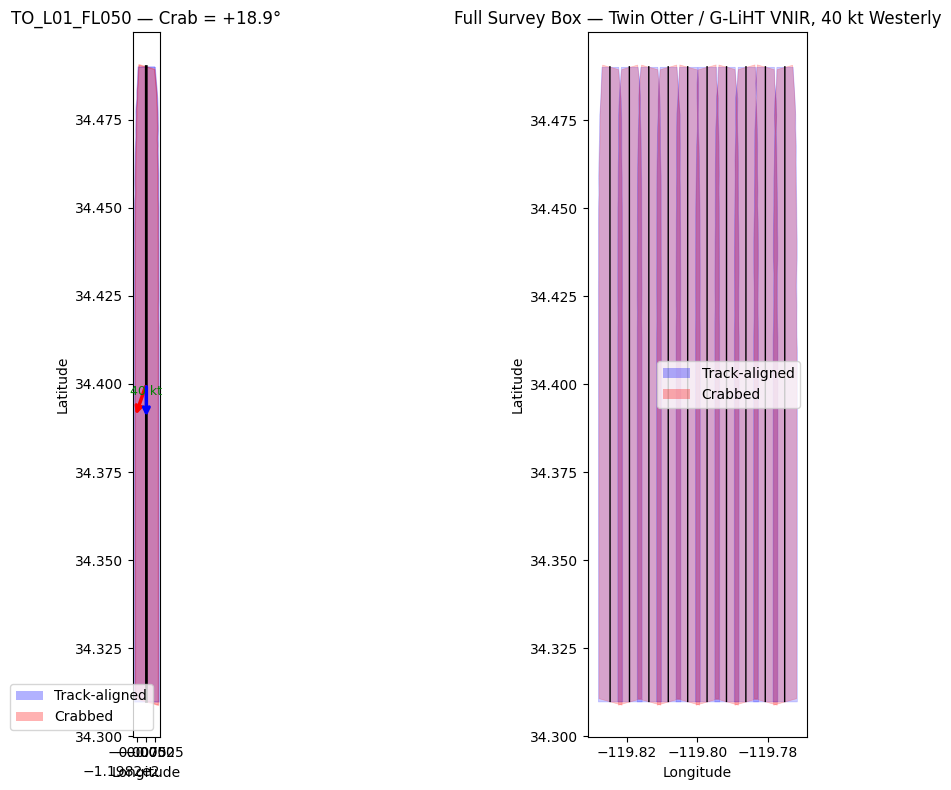

Track-aligned mean width: 650 m
Crabbed mean width:       709 m
Effective width loss:      -9.1%


In [4]:
# Single-line close-up + full-box overlay
fl = lines_to[0]
fl_row = fl_wind[fl_wind["segment_name"] == fl.site_name].iloc[0]
crab = fl_row["crab_angle_deg"]

swath_track = generate_swath_polygon(fl, sensor, along_precision=200.0)
swath_crab = generate_swath_polygon(
    fl, sensor, along_precision=200.0,
    heading_mode="crabbed", crab_angle_deg=crab,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Left: single line close-up with arrows
gpd.GeoSeries([swath_track]).plot(ax=axes[0], alpha=0.3, color="blue", edgecolor="blue")
gpd.GeoSeries([swath_crab]).plot(ax=axes[0], alpha=0.3, color="red", edgecolor="red")
x, y = fl.geometry.xy
axes[0].plot(x, y, "k-", linewidth=2)

mid_lat, mid_lon = (fl.lat1 + fl.lat2) / 2, (fl.lon1 + fl.lon2) / 2
arrow = 0.01
hdg_rad = np.radians(fl_row["wind_corrected_heading"])
trk_rad = np.radians(fl_row["planned_track"])
axes[0].annotate("", xy=(mid_lon + arrow*np.sin(hdg_rad), mid_lat + arrow*np.cos(hdg_rad)),
                 xytext=(mid_lon, mid_lat),
                 arrowprops=dict(arrowstyle="->", color="red", lw=2.5))
axes[0].annotate("", xy=(mid_lon + arrow*np.sin(trk_rad), mid_lat + arrow*np.cos(trk_rad)),
                 xytext=(mid_lon, mid_lat),
                 arrowprops=dict(arrowstyle="->", color="blue", lw=2.5))
axes[0].annotate("", xy=(mid_lon + 0.008, mid_lat),
                 xytext=(mid_lon - 0.008, mid_lat),
                 arrowprops=dict(arrowstyle="->", color="green", lw=2, linestyle="--"))
axes[0].text(mid_lon, mid_lat - 0.003, "40 kt", ha="center", color="green", fontsize=9)
axes[0].set_title(f"{fl.site_name} \u2014 Crab = {crab:+.1f}\u00b0")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].set_aspect("equal")

from matplotlib.patches import Patch
axes[0].legend(handles=[
    Patch(facecolor="blue", alpha=0.3, label="Track-aligned"),
    Patch(facecolor="red", alpha=0.3, label="Crabbed"),
], loc="lower right")

# Right: full flight box overlay
for line in lines_to:
    # Track-aligned
    sw_t = generate_swath_polygon(line, sensor, along_precision=500.0)
    gpd.GeoSeries([sw_t]).plot(ax=axes[1], alpha=0.2, color="blue", edgecolor="blue", linewidth=0.5)
    # Crabbed
    lrow = fl_wind[fl_wind["segment_name"] == line.site_name]
    if len(lrow) > 0:
        c = lrow.iloc[0]["crab_angle_deg"]
        sw_c = generate_swath_polygon(line, sensor, along_precision=500.0,
                                      heading_mode="crabbed", crab_angle_deg=c)
        gpd.GeoSeries([sw_c]).plot(ax=axes[1], alpha=0.2, color="red", edgecolor="red", linewidth=0.5)
    x, y = line.geometry.xy
    axes[1].plot(x, y, "k-", linewidth=1)

axes[1].legend(handles=[
    Patch(facecolor="blue", alpha=0.3, label="Track-aligned"),
    Patch(facecolor="red", alpha=0.3, label="Crabbed"),
])
axes[1].set_title("Full Survey Box \u2014 Twin Otter / G-LiHT VNIR, 40 kt Westerly")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.show()

w_t = calculate_swath_widths(swath_track)
w_c = calculate_swath_widths(swath_crab)
print(f"Track-aligned mean width: {w_t['mean_width']:.0f} m")
print(f"Crabbed mean width:       {w_c['mean_width']:.0f} m")
print(f"Effective width loss:      {(1 - w_c['mean_width']/w_t['mean_width'])*100:.1f}%")


## 11. ER-2 / AVIRIS Classic with 100 kt Jet Stream Crosswind

The ER-2 cruises at ~410 kt at 65,000 ft.  At this altitude, jet stream
crosswinds of 100 kt are common.  


In [12]:
er2 = NASA_ER2()
sensor_er2 = AVIRISClassic()

# East-west lines at 65,000 ft with 100 kt crosswind from south
lines_er2 = box_around_center_line(
    instrument=sensor_er2,
    altitude_msl=ureg.Quantity(65000, "feet"),
    lat0=35.0, lon0=-118.0,
    azimuth=90.0,  # east-west lines
    box_length=ureg.Quantity(100, "km"),
    box_width=ureg.Quantity(20, "km"),
    box_name="ER2",
    overlap=15,
)

wind_100kt_south = ConstantWindField(100 * ureg.knot, 180.0)  # from south

plan_er2_calm = compute_flight_plan(
    aircraft=er2, flight_sequence=lines_er2,
)
plan_er2_wind = compute_flight_plan(
    aircraft=er2, flight_sequence=lines_er2,
    wind_source=wind_100kt_south,
)

fl_er2_calm = plan_er2_calm[plan_er2_calm["segment_type"] == "flight_line"]
fl_er2_wind = plan_er2_wind[plan_er2_wind["segment_type"] == "flight_line"]

print(f"ER-2 / AVIRIS Classic at {lines_er2[0].altitude_msl.to(ureg.feet):.0f}")
print(f"  TAS: {er2.cruise_speed_at(lines_er2[0].altitude_msl).to(ureg.knot):.0f}")
print(f"  Sensor FOV: {sensor_er2.half_angle * 2:.0f}\u00b0")
print(f"  {len(lines_er2)} lines, 100 kt jet stream from south")
print()
print(f"{'Line':8s}  {'Track':>6s}  {'Heading':>8s}  {'Crab':>7s}  {'GS':>7s}  {'Time':>12s}")
print("-" * 65)

for (_, r0), (_, r1) in zip(fl_er2_calm.iterrows(), fl_er2_wind.iterrows()):
    print(
        f"{r1['segment_name']:8s}  "
        f"{r1['planned_track']:6.0f}\u00b0  "
        f"{r1['wind_corrected_heading']:7.1f}\u00b0  "
        f"{r1['crab_angle_deg']:+6.1f}\u00b0  "
        f"{r1['groundspeed_kts']:6.1f}kt  "
        f"{r1['time_to_segment']:5.1f}m (was {r0['time_to_segment']:.1f}m)"
    )


ER-2 / AVIRIS Classic at 65000 foot
  TAS: 410 knot
  Sensor FOV: 34°
  2 lines, 100 kt jet stream from south

Line       Track   Heading     Crab       GS          Time
-----------------------------------------------------------------
ER2_L01_FL650     270°    256.3°   -14.1°   398.2kt    9.0m (was 8.8m)
ER2_L02_FL650      90°    103.7°   +14.1°   398.2kt    9.0m (was 8.8m)


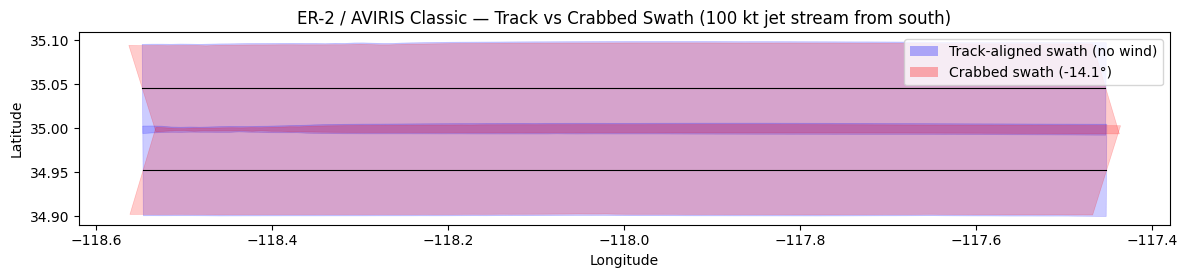

In [11]:
# ER-2 flight box: overlay track-aligned and crabbed swaths
fig, ax = plt.subplots(figsize=(12, 8))

for line in lines_er2:
    # Track-aligned (blue)
    sw_track = generate_swath_polygon(line, sensor_er2, along_precision=1000.0)
    gpd.GeoSeries([sw_track]).plot(ax=ax, alpha=0.2, color="blue", edgecolor="blue", linewidth=0.5)

    # Crabbed (red)
    lrow = fl_er2_wind[fl_er2_wind["segment_name"] == line.site_name]
    if len(lrow) > 0:
        c = lrow.iloc[0]["crab_angle_deg"]
        sw_crab = generate_swath_polygon(line, sensor_er2, along_precision=1000.0,
                                         heading_mode="crabbed", crab_angle_deg=c)
        gpd.GeoSeries([sw_crab]).plot(ax=ax, alpha=0.2, color="red", edgecolor="red", linewidth=0.5)

    x, y = line.geometry.xy
    ax.plot(x, y, "k-", linewidth=0.8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor="blue", alpha=0.3, label="Track-aligned swath (no wind)"),
    Patch(facecolor="red", alpha=0.3, label=f"Crabbed swath ({fl_er2_wind['crab_angle_deg'].iloc[0]:+.1f}\u00b0)"),
])
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("ER-2 / AVIRIS Classic \u2014 Track vs Crabbed Swath (100 kt jet stream from south)")
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


## 12. Trochoidal Dubins Paths Under Wind

Transit arcs between flight lines use Dubins minimum-radius paths.
In still air these are clean circular arcs.  Under wind, the
air-frame circles drift, producing **trochoids** — the curves traced
by a point on a rolling circle.

Below we compare still-air (circular) vs wind (trochoidal) transit
paths for the Twin Otter survey with a 40 kt westerly wind.


In [7]:
# Build Dubins transit paths between consecutive Twin Otter flight lines
cruise_speed = twin_otter.cruise_speed_at(lines_to[0].altitude_msl)
bank_angle = twin_otter.max_bank_angle
pitch_min, pitch_max = twin_otter.pitch_limits(cruise_speed)

# 40 kt westerly wind (blows eastward): u > 0, v = 0
wind_u_mps = (40 * ureg.knot).m_as("m/s")
wind_vec = (wind_u_mps, 0.0)

print(f"Cruise TAS: {cruise_speed.to(ureg.knot):.0f}")
print(f"Bank angle: {bank_angle}\u00b0")
print(f"Wind: 40 kt from west (u={wind_u_mps:.1f} m/s east)")

transit_pairs = []
for i in range(len(lines_to) - 1):
    transit_pairs.append((
        lines_to[i].waypoint2, lines_to[i + 1].waypoint1,
        f"{lines_to[i].site_name} \u2192 {lines_to[i + 1].site_name}",
    ))

paths_still = []
paths_wind = []

for start_wp, end_wp, label in transit_pairs:
    p_still = DubinsPath3D(
        start=start_wp, end=end_wp,
        speed=cruise_speed, bank_angle=bank_angle,
        pitch_min=pitch_min, pitch_max=pitch_max, step_size=50.0,
    )
    p_wind = DubinsPath3D(
        start=start_wp, end=end_wp,
        speed=cruise_speed, bank_angle=bank_angle,
        pitch_min=pitch_min, pitch_max=pitch_max, step_size=50.0,
        wind=wind_vec,
    )
    paths_still.append((label, p_still))
    paths_wind.append((label, p_wind))
    print(f"\n{label}:")
    print(f"  Still air: {p_still.length.to(ureg.km):.1f}")
    print(f"  With wind: {p_wind.length.to(ureg.km):.1f}")


Cruise TAS: 124 knot
Bank angle: 15.0°
Wind: 40 kt from west (u=20.6 m/s east)

TO_L01_FL050 → TO_L02_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L02_FL050 → TO_L03_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L03_FL050 → TO_L04_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L04_FL050 → TO_L05_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L05_FL050 → TO_L06_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L06_FL050 → TO_L07_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L07_FL050 → TO_L08_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L08_FL050 → TO_L09_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer

TO_L09_FL050 → TO_L10_FL050:
  Still air: 10.7 kilometer
  With wind: 8.2 kilometer


In [8]:
# Interactive map: circular vs trochoidal transit arcs
center_lat = np.mean([fl.lat1 for fl in lines_to])
center_lon = np.mean([fl.lon1 for fl in lines_to])

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12, tiles="CartoDB positron",
)

# Flight lines
for fl in lines_to:
    coords = [(lat, lon) for lon, lat in fl.geometry.coords]
    folium.PolyLine(
        coords, color="steelblue", weight=4, opacity=0.9,
        tooltip=fl.site_name,
    ).add_to(m)

# Still-air transits (dashed gray)
for label, path in paths_still:
    coords = [(lat, lon) for lon, lat in path.geometry.coords]
    folium.PolyLine(
        coords, color="gray", weight=3, opacity=0.8,
        dash_array="6", tooltip=f"{label} (still air)",
    ).add_to(m)

# Wind transits (solid red)
for label, path in paths_wind:
    coords = [(lat, lon) for lon, lat in path.geometry.coords]
    folium.PolyLine(
        coords, color="crimson", weight=3, opacity=0.9,
        tooltip=f"{label} (40 kt westerly)",
    ).add_to(m)

# Legend
legend_html = """
<div style="position:fixed; bottom:30px; right:30px; z-index:1000;
     background:white; padding:10px 14px; border-radius:6px;
     border:1px solid #ccc; font-size:12px; line-height:1.6;">
  <b>Transit paths</b><br>
  <span style="color:gray;">&mdash; &mdash;</span> Still air (circular arcs)<br>
  <span style="color:crimson;">&mdash;&mdash;</span> 40 kt wind (trochoidal arcs)<br>
  <span style="color:steelblue;">&mdash;&mdash;</span> Flight lines
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m


## 13. Total Mission Timing Impact

Crab angle affects **total** mission time, not just data-collection legs:

- **Groundspeed reduction**: `GS = TAS * cos(crab) + tailwind`.  Even with
  zero along-track wind, the `cos(crab)` factor slows the aircraft.
- **Alternating lines**: On a racetrack pattern, the crosswind component
  flips sign between eastbound and westbound legs, but the *magnitude*
  of the crab is the same.  The groundspeed penalty is symmetric.
- **Transit legs**: Also affected by wind, though transits use Dubins paths
  with their own wind correction.


In [9]:
# Total mission timing comparison
for label, plan_c, plan_w in [
    ("Twin Otter / G-LiHT VNIR (40 kt xwind)", plan_calm, plan_windy),
    ("ER-2 / AVIRIS Classic (100 kt jet stream)", plan_er2_calm, plan_er2_wind),
]:
    fl_c = plan_c[plan_c["segment_type"] == "flight_line"]
    fl_w = plan_w[plan_w["segment_type"] == "flight_line"]

    data_calm = fl_c["time_to_segment"].sum()
    data_wind = fl_w["time_to_segment"].sum()
    total_calm = plan_c["time_to_segment"].sum()
    total_wind = plan_w["time_to_segment"].sum()
    mean_crab = fl_w["crab_angle_deg"].abs().mean()

    print(f"{label}:")
    print(f"  Mean |crab|:       {mean_crab:.1f}\u00b0")
    print(f"  Data-collection:  {data_calm:.1f} \u2192 {data_wind:.1f} min  ({(data_wind-data_calm)/data_calm*100:+.1f}%)")
    print(f"  Total mission:    {total_calm:.1f} \u2192 {total_wind:.1f} min  ({(total_wind-total_calm)/total_calm*100:+.1f}%)")
    print()


Twin Otter / G-LiHT VNIR (40 kt xwind):
  Mean |crab|:       18.9°
  Data-collection:  81.6 → 86.3 min  (+5.7%)
  Total mission:    111.6 → 115.2 min  (+3.2%)

ER-2 / AVIRIS Classic (100 kt jet stream):
  Mean |crab|:       14.1°
  Data-collection:  17.6 → 18.1 min  (+2.9%)
  Total mission:    20.9 → 20.7 min  (-1.0%)



## Key Equations

Given desired track azimuth and wind vector (u, v):

| Quantity | Formula |
|----------|--------|
| Tailwind | `u * sin(track) + v * cos(track)` |
| Crosswind | `u * cos(track) - v * sin(track)` |
| Crab angle | `asin(-crosswind / TAS)` |
| Heading | `track + crab` |
| Groundspeed | `TAS * cos(crab) + tailwind` |

The swath rotates with the heading, not the track.  For a nadir-looking
instrument with half-angle `θ`, the effective perpendicular swath width
decreases approximately as `cos(crab)` relative to the track-aligned case.

## Summary

### Wind Data Sources

| Class / Function | Purpose |
|-----------------|--------|
| `StillAirField()` | Zero wind baseline |
| `ConstantWindField(speed, direction)` | Uniform wind everywhere |
| `MERRA2WindField(...)` | Historical reanalysis via OPeNDAP |
| `GFSWindField(...)` | NOAA GFS operational forecast |
| `GMAOWindField(...)` | NASA GMAO near-real-time analysis |
| `wind_field_from_plan(source, ...)` | Auto-configure from flight plan |

### Wind Effects on Surveys

| Quantity | Formula |
|----------|--------|
| Tailwind | `u * sin(track) + v * cos(track)` |
| Crosswind | `u * cos(track) - v * sin(track)` |
| Crab angle | `asin(-crosswind / TAS)` |
| Heading | `track + crab` |
| Groundspeed | `TAS * cos(crab) + tailwind` |

The swath rotates with the heading, not the track. Transit arcs
become trochoids under wind. Both effects are computed automatically
by `compute_flight_plan` when a wind source is provided.
